In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv("Penguins.csv")
print(df.head(10))
print("--------------------------")
print("Info. of Dataset : ", df.info)
print("--------------------------")
print("Describe Dataset : ", df.describe())
print("--------------------------")
print("Shape : ", df.shape)

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   
6  Adelie  Torgersen            38.9           17.8              181.0   
7  Adelie  Torgersen            39.2           19.6              195.0   
8  Adelie  Torgersen            34.1           18.1              193.0   
9  Adelie  Torgersen            42.0           20.2              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  
5       3650.0    MALE  
6       36

In [91]:
# List out the columns :
# 1) Categorical Columns :
#       Species , Island , Sex

# 2) Numeric Columns :
#       bill_ length , bill_depth , flipper_length , body_mass

In [92]:
# Questions :
#   1) Is there any correlation between bill_length and bill_depth ?
#   2) Can you predict the island where penguins lived based on their bill_length , bill_depth and flipper_length ?
#   3) Which species is the heaviest on average?

In [93]:
print("Check Null Values :\n", df.isna().sum())

Check Null Values :
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [94]:
df['sex'] = df['sex'].fillna('Unknown')
df['bill_length_mm'] = df['bill_length_mm'].fillna(df['bill_length_mm'].mean())
df['bill_depth_mm'] = df['bill_depth_mm'].fillna(df['bill_depth_mm'].mean())
df['flipper_length_mm'] = df['flipper_length_mm'].fillna(df['flipper_length_mm'].mean())
df['body_mass_g'] = df['body_mass_g'].fillna(df['body_mass_g'].mean())

print(df.isna().sum())
print(df.head(10))
# All columns are the core features of penguins so we shouldn't drop any.

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen        39.10000       18.70000         181.000000   
1  Adelie  Torgersen        39.50000       17.40000         186.000000   
2  Adelie  Torgersen        40.30000       18.00000         195.000000   
3  Adelie  Torgersen        43.92193       17.15117         200.915205   
4  Adelie  Torgersen        36.70000       19.30000         193.000000   
5  Adelie  Torgersen        39.30000       20.60000         190.000000   
6  Adelie  Torgersen        38.90000       17.80000         181.000000   
7  Adelie  Torgersen        39.20000       19.60000         195.000000   
8  Adelie  Torgersen        34.10000       18.10000         193.000000   
9  Adelie  Torgersen        42.00000       20.20000         190.000000   

   body_mas

In [95]:
filtered_penguins = df[
    (df["bill_length_mm"] > 45) &
    (df["body_mass_g"] > 4500)
]

print("Filtered Penguins:")
print(filtered_penguins.head(10))

Filtered Penguins:
       species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
111     Adelie  Biscoe            45.6           20.3              191.0   
181  Chinstrap   Dream            52.8           20.0              205.0   
189  Chinstrap   Dream            52.0           20.7              210.0   
221     Gentoo  Biscoe            50.0           16.3              230.0   
223     Gentoo  Biscoe            50.0           15.2              218.0   
224     Gentoo  Biscoe            47.6           14.5              215.0   
225     Gentoo  Biscoe            46.5           13.5              210.0   
226     Gentoo  Biscoe            45.4           14.6              211.0   
227     Gentoo  Biscoe            46.7           15.3              219.0   
229     Gentoo  Biscoe            46.8           15.4              215.0   

     body_mass_g     sex  
111       4600.0    MALE  
181       4550.0    MALE  
189       4800.0    MALE  
221       5700.0    MALE  
223      

In [113]:
df["bill_size"] = df["bill_length_mm"].apply( lambda x: "Long" if x >= 40 else "Short")

print(df[["bill_length_mm", "bill_size"]].head(10))

   bill_length_mm bill_size
0        39.10000     Short
1        39.50000     Short
2        40.30000      Long
3        43.92193      Long
4        36.70000     Short
5        39.30000     Short
6        38.90000     Short
7        39.20000     Short
8        34.10000     Short
9        42.00000      Long


In [97]:
def size_category(body_mass):
    if body_mass <= 3300:
        return "Small"
    elif body_mass <= 4000:
        return "Medium"
    else:
        return "Large"

df["size_category"] = df["body_mass_g"].apply(size_category)
print(df.head(10))

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen        39.10000       18.70000         181.000000   
1  Adelie  Torgersen        39.50000       17.40000         186.000000   
2  Adelie  Torgersen        40.30000       18.00000         195.000000   
3  Adelie  Torgersen        43.92193       17.15117         200.915205   
4  Adelie  Torgersen        36.70000       19.30000         193.000000   
5  Adelie  Torgersen        39.30000       20.60000         190.000000   
6  Adelie  Torgersen        38.90000       17.80000         181.000000   
7  Adelie  Torgersen        39.20000       19.60000         195.000000   
8  Adelie  Torgersen        34.10000       18.10000         193.000000   
9  Adelie  Torgersen        42.00000       20.20000         190.000000   

   body_mass_g      sex bill_size size_category  
0  3750.000000     MALE     Short        Medium  
1  3800.000000   FEMALE     Short        Medium  
2  3250.000000   FEMALE      Long  

In [98]:
df["weight"] = np.where(df["body_mass_g"] >= 4000, "Heavy", "Light")
print(df[["body_mass_g", "weight"]].head(10))

   body_mass_g weight
0  3750.000000  Light
1  3800.000000  Light
2  3250.000000  Light
3  4201.754386  Heavy
4  3450.000000  Light
5  3650.000000  Light
6  3625.000000  Light
7  4675.000000  Heavy
8  3475.000000  Light
9  4250.000000  Heavy


In [99]:
sorted_cols = df.sort_values(["size_category", "body_mass_g"], ascending=[False, True])
print(sorted_cols.head(15))

       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
190  Chinstrap      Dream            46.9           16.6              192.0   
58      Adelie     Biscoe            36.5           16.6              181.0   
64      Adelie     Biscoe            36.4           17.1              184.0   
54      Adelie     Biscoe            34.5           18.1              187.0   
98      Adelie      Dream            33.1           16.1              178.0   
116     Adelie  Torgersen            38.6           17.0              188.0   
174  Chinstrap      Dream            43.2           16.6              187.0   
104     Adelie     Biscoe            37.9           18.6              193.0   
47      Adelie      Dream            37.5           18.9              179.0   
44      Adelie      Dream            37.0           16.9              185.0   
144     Adelie      Dream            37.3           16.8              192.0   
68      Adelie  Torgersen            35.9           

In [100]:
print(df.groupby(['species'])['body_mass_g'].mean())
print()

# If we Cal. Body Mass a/c to their Sex.
print(df.groupby(['species', 'sex'])['body_mass_g'].mean())

species
Adelie       3703.958910
Chinstrap    3733.088235
Gentoo       5068.965761
Name: body_mass_g, dtype: float64

species    sex    
Adelie     FEMALE     3368.835616
           MALE       4043.493151
           Unknown    3650.292398
Chinstrap  FEMALE     3527.205882
           MALE       3938.970588
Gentoo     FEMALE     4679.741379
           MALE       5484.836066
           Unknown    4510.350877
Name: body_mass_g, dtype: float64


In [101]:
bill_stats = df.groupby("species")["bill_length_mm"].agg(["mean", "min", "max", "count"])

print("Bill Length Statistics by Species:")
print(bill_stats)

Bill Length Statistics by Species:
                mean   min   max  count
species                                
Adelie     38.825144  32.1  46.0    152
Chinstrap  48.833824  40.9  58.0     68
Gentoo     47.475983  40.9  59.6    124


In [102]:
bill_stats = bill_stats.sort_values("mean").reindex()

print("Ordered Species according to thier Bill Length:")
print(bill_stats)

Ordered Species according to thier Bill Length:
                mean   min   max  count
species                                
Adelie     38.825144  32.1  46.0    152
Gentoo     47.475983  40.9  59.6    124
Chinstrap  48.833824  40.9  58.0     68


                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.235053
bill_depth_mm        -0.235053       1.000000


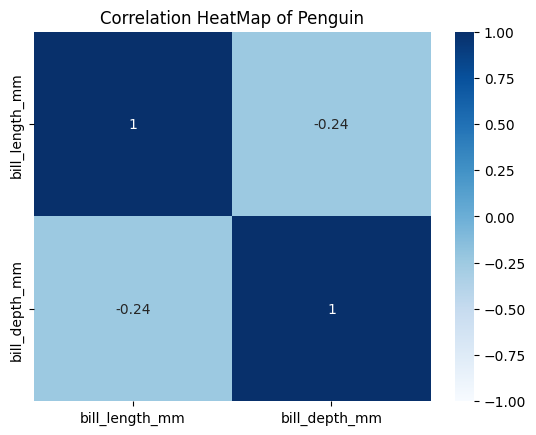

In [103]:
correlation_matrix = df[["bill_length_mm","bill_depth_mm"]].corr()
print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", vmin=-1, vmax=1) #Annot shows the value of upper side of box
plt.title("Correlation HeatMap of Penguin")
plt.show()

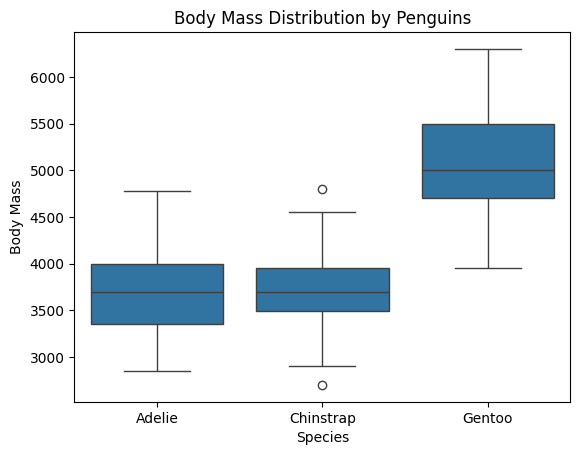

In [104]:
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Body Mass Distribution by Penguins")
plt.xlabel("Species")
plt.ylabel("Body Mass")
plt.show()


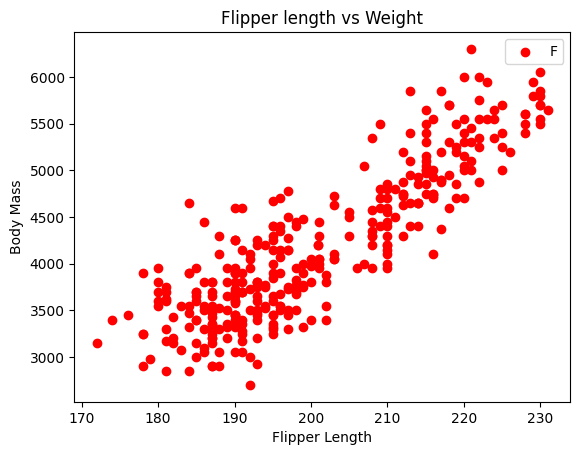

In [105]:
plt.scatter(df["flipper_length_mm"], df["body_mass_g"], color="red")
plt.title("Flipper length vs Weight")
plt.xlabel("Flipper Length")
plt.ylabel("Body Mass")
plt.legend(labels="Flipper_length")
plt.savefig("Filpper_length_VS_Weight.png")
plt.show()

In [106]:
island_info = pd.DataFrame({
    "island": ["Biscoe", "Dream", "Torgersen"],
    "location_type": ["Large Island", "Normal Island", "Small Island"]
})
print(island_info)
print()

merged = pd.merge(df, island_info, on="island", how="left")
print(merged.head(25))
print(merged.shape)
print()

# merged = pd.merge(df, island_info, on="island", how="inner")
# print(merged.head(25))
# print(merged.shape)

      island  location_type
0     Biscoe   Large Island
1      Dream  Normal Island
2  Torgersen   Small Island

   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0   Adelie  Torgersen        39.10000       18.70000         181.000000   
1   Adelie  Torgersen        39.50000       17.40000         186.000000   
2   Adelie  Torgersen        40.30000       18.00000         195.000000   
3   Adelie  Torgersen        43.92193       17.15117         200.915205   
4   Adelie  Torgersen        36.70000       19.30000         193.000000   
5   Adelie  Torgersen        39.30000       20.60000         190.000000   
6   Adelie  Torgersen        38.90000       17.80000         181.000000   
7   Adelie  Torgersen        39.20000       19.60000         195.000000   
8   Adelie  Torgersen        34.10000       18.10000         193.000000   
9   Adelie  Torgersen        42.00000       20.20000         190.000000   
10  Adelie  Torgersen        37.80000       17.10000         1

In [107]:
categorical_columns = [
    col for col in ["species", "island", "sex","bill_size","size_category","weight"]
    if col in df.columns
]
print("Categorical Columns:")
print(categorical_columns)


numeric_columns = [
    col for col in ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
    if col in df.columns
]

print("\nNumeric Columns:")
print(numeric_columns)

Categorical Columns:
['species', 'island', 'sex', 'bill_size', 'size_category', 'weight']

Numeric Columns:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [111]:
print(df.columns)
print()
print(df.shape)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'bill_size', 'size_category',
       'weight'],
      dtype='object')

(344, 10)


In [ ]:
# Conclusion :
#   1. Bill length vs. bill depth
#         Yes, there a relationship exits between bill length and bill depth, although not a strong one. It means that any changes in bill length will probably cause some changes in bill depth, although not always.
#   2. Island prediction
#         Bill length, bill depth, and flipper length can be used to predict the island where a penguins lived. Since there exist differences between penguins living on various islands, the measures mentioned above will give the possible island.
#   3. Heaviest penguin
#         Gentoo penguins are the heaviest of all. The average body mass of Gentoo penguins is higher than the average body mass of Adelie and Chinstrap penguins.